# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [3]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
contagem = df['quality'].value_counts().reset_index()
contagem.columns = ['quality', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='quality', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável quality')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='quality', yaxis_title='Frequência')
fig.show()

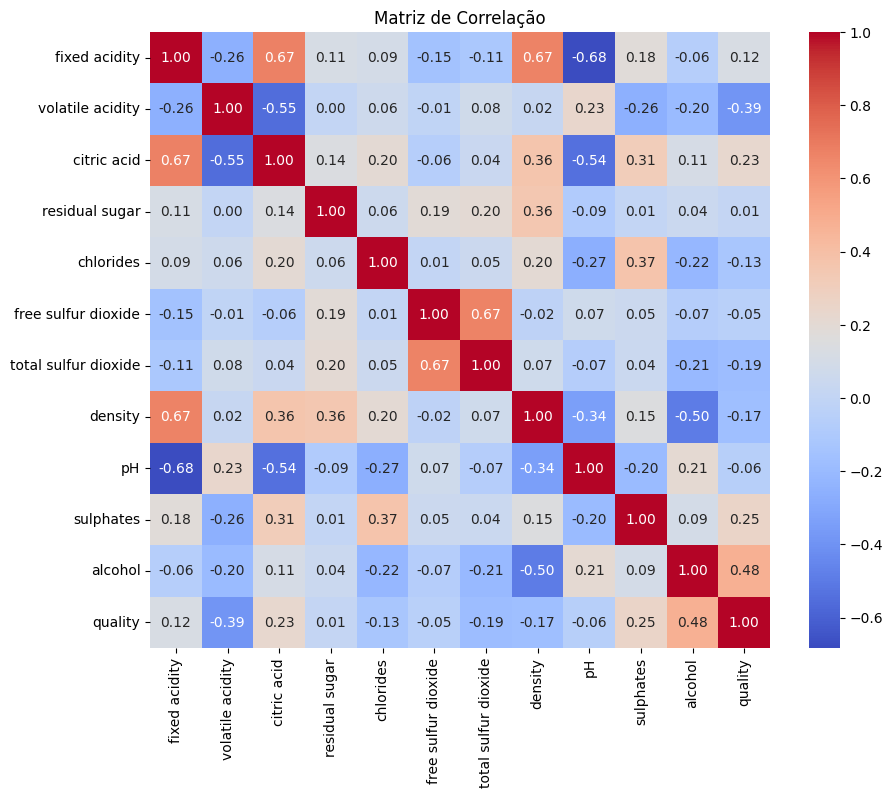

In [4]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Variáveis com maior correlação entre si:
- ph e fixed acidity (0.68%)
- total sulfur dioxide e free sulfur dioxide (0.67%)
- citric acid e fixed acidity (0.67%)
- density e fixed acidity (0.67%)
- citric acid e volatile acidity (-0.55%)
- ph e citric acid (-0.54%)
- density e alcohol (-0.50%)
- sulphates e cholorides (0.37%)
- density e citric acid (0.36%)
- density e residual sugar (0.36%) 

Variáveis com maior correlação com a target (quality):
- alcohol (0.48%)
- volatile acidity (-0.39%)
- sulphates (0.25%)
- citric acid (0.23%)

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [ ]:
# X = df[['alcohol', 'volatile acidity', 'sulphates', 'citric acid']]
# Y = df['quality']

OBS: Utilizei todas as variáveis pois o modelo apresentou desempenho inferior quando utilizado somente as variáveis com maior correlação com a target (quality).

In [3]:
X = df.drop('quality', axis=1)
Y = df['quality']

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, Y_train)

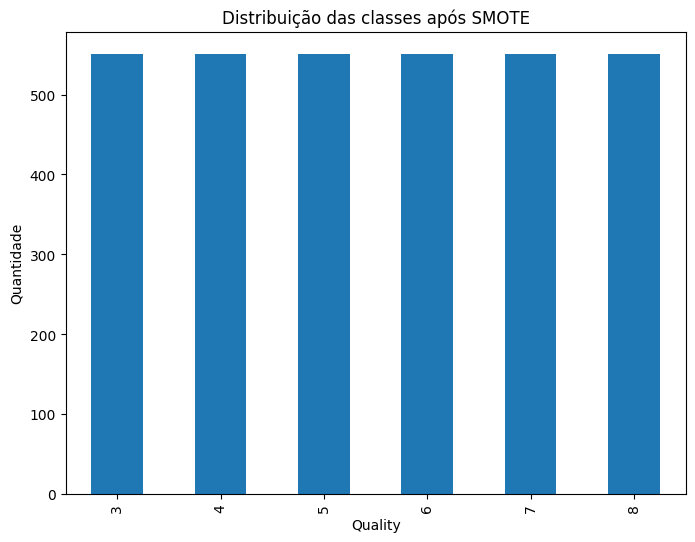

In [11]:
counts = y_train_balanced.value_counts().sort_index()

plt.figure(figsize=(8,6))
counts.plot(kind='bar')
plt.title("Distribuição das classes após SMOTE")
plt.xlabel("Quality")
plt.ylabel("Quantidade")
plt.show()

In [12]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_balanced)
X_test_scaled = sc.transform(X_test)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [5]:
random_forest = RandomForestClassifier(random_state=42)

In [14]:
random_forest.fit(X_train_scaled, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


In [15]:
Y_pred = random_forest.predict(X_test_scaled)

In [16]:
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.62
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.16      0.30      0.21        10
           5       0.72      0.68      0.70       130
           6       0.65      0.58      0.62       132
           7       0.54      0.64      0.59        42
           8       0.17      0.20      0.18         5

    accuracy                           0.62       320
   macro avg       0.37      0.40      0.38       320
weighted avg       0.64      0.62      0.63       320

Matriz de Confusão:
 [[ 0  1  0  0  0  0]
 [ 0  3  5  2  0  0]
 [ 3  8 89 27  3  0]
 [ 1  7 29 77 16  2]
 [ 0  0  0 12 27  3]
 [ 0  0  0  0  4  1]]


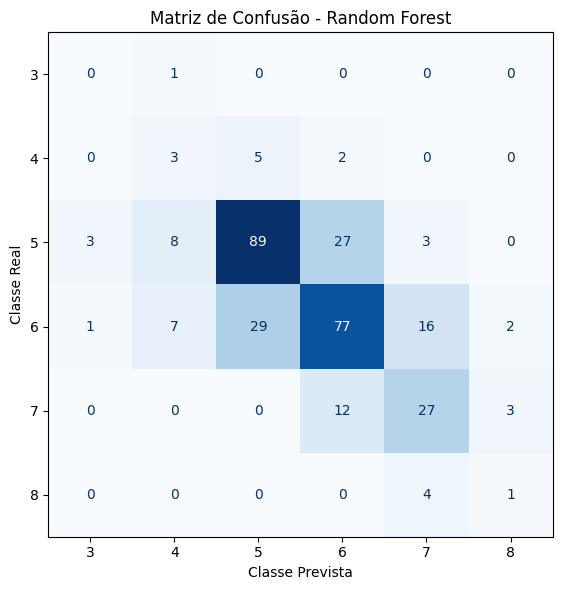

In [ ]:
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=random_forest.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

O modelo Random Forest obteve uma acurácia de 62%, indicando que classificou corretamente aproximadamente 62% das amostras do conjunto de teste. Analisando as métricas por classe:
- Classes 5 e 6: apresentaram os melhores resultados. A classe 5 obteve precisão de 0.72, recall de 0.68 e F1-score de 0.70, enquanto a classe 6 alcançou precisão de 0.65, recall de 0.58 e F1-score de 0.62. Isso demonstra que o modelo consegue identificar relativamente bem essas classes, provavelmente porque elas representam a maior parte das amostras do conjunto de dados.
- Classe 7: apresentou desempenho intermediário, com F1-score de 0.59, indicando que o modelo consegue identificá-la razoavelmente bem, embora ainda ocorra confusão ao classificar.
- Classes 3, 4 e 8: tiveram os piores resultados. A classe 3 não teve nenhuma amostra corretamente classificada (precision, recall e F1-score iguais a 0). As classes 4 e 8 apresentaram métricas muito baixas, indicando dificuldade do modelo em classificar elas corretamente.

A matriz de confusão reforça essa conclusão. As maiores confusões ocorreram entre:
- Classe 5 classificada como 6 (27 amostras)
- Classe 6 classificada como 5 (29 amostras)
- Classe 6 classificada como 7 (16 amostras)
- Classe 7 classificada como 6 (12 amostras)

O modelo apresentou maior dificuldade para prever as classes 3, 4 e 8, principalmente a classe 3, que não teve nenhuma previsão correta. Essa dificuldade está diretamente relacionada ao desbalanceamento dos dados. Essas classes possuem poucas amostras no conjunto original, fazendo com que o modelo tenha menos exemplos para aprender seus padrões durante o treinamento. Como consequência, ele tende a classificar essas observações como pertencentes às classes mais frequentes, especialmente 5 e 6.

Embora tenha sido utilizado o SMOTE e StandardScaler para balancear e padronizar o conjunto de treinamento, a técnica SMOTE possui limitações quando há pouquíssimos exemplos reais de determinada classe. No caso da classe 3, por exemplo, havia apenas uma amostra no conjunto de teste, e o número de exemplos reais disponíveis para gerar amostras sintéticas no treinamento também era muito reduzido. Assim, mesmo com o balanceamento, o modelo continuou apresentando baixo desempenho nessas classes.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [19]:
random_search = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid,
                n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [20]:
random_search.fit(X_train_scaled, y_train_balanced)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

In [21]:
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [12]:
best_random_forest_model = random_search.best_estimator_
best_random_forest_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
Y_pred = best_random_forest_model.predict(X_test_scaled)

In [24]:
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.63
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.30      0.22        10
           5       0.74      0.68      0.71       130
           6       0.66      0.63      0.64       132
           7       0.59      0.64      0.61        42
           8       0.12      0.20      0.15         5

    accuracy                           0.63       320
   macro avg       0.38      0.41      0.39       320
weighted avg       0.66      0.63      0.64       320

Matriz de Confusão:
 [[ 0  1  0  0  0  0]
 [ 0  3  5  2  0  0]
 [ 3  8 89 28  2  0]
 [ 0  5 26 83 14  4]
 [ 0  0  0 12 27  3]
 [ 0  0  0  1  3  1]]


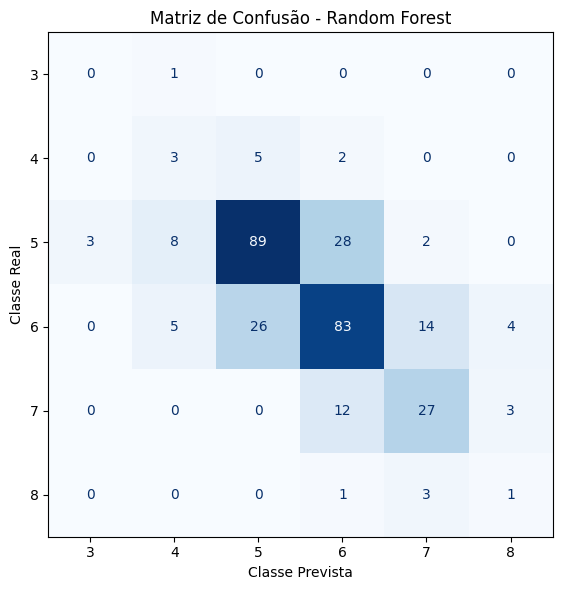

In [25]:
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=random_forest.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

Após a aplicação do Random Search para otimização dos hiperparâmetros do Random Forest, o modelo apresentou uma acurácia de 63%, representando um desempenho ligeiramente superior ao modelo anterior. 

As classes 5 e 6 continuaram sendo as mais bem classificadas, apresentando F1-scores de 0.71 e 0.64, respectivamente. A classe 7 também apresentou um bom desempenho, com F1-score de 0.61. Esses resultados mostram que o modelo consegue identificar adequadamente as classes com maior quantidade de exemplos.

Por outro lado, as classes 3, 4 e 8 continuaram apresentando baixo desempenho. A classe 3 não teve nenhuma amostra corretamente classificada, enquanto as classes 4 e 8 obtiveram baixos valores de precisão, recall e F1-score. Esse comportamento evidencia que o modelo ainda encontra dificuldades para aprender os padrões das classes minoritárias.

A matriz de confusão confirma que os maiores erros continuam ocorrendo entre as classes:
- Classe 5 classificada como 6 (28 amostras)
- Classe 6 classificada como 5 (26 amostras)
- Classe 6 classificada como 7 (14 amostras)
- Classe 7 classificada como 6 (12 amostras)

Os resultados indicam que o ajuste dos hiperparâmetros permitiu ao modelo generalizar melhor os dados, melhorando principalmente a classificação das classes mais frequentes (5, 6 e 7). Entretanto, as melhorias foram modestas. As classes minoritárias (3, 4 e 8) continuaram apresentando baixo desempenho, mesmo após a otimização. Isso sugere que a principal limitação do modelo não está apenas na escolha dos hiperparâmetros, mas também no forte desbalanceamento dos dados e na pequena quantidade de exemplos dessas classes. Mesmo com a utilização do SMOTE, a geração de amostras sintéticas não foi suficiente para representar adequadamente essas classes.

De modo geral, o Random Search contribuiu para aumentar a qualidade das previsões, porém ainda existem limitações relacionadas à distribuição das classes.

# Utilizando 'class_weight': 

In [ ]:
# random_forest = RandomForestClassifier(random_state=42)

In [ ]:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None],
#     'class_weight': [None, 'balanced', 'balanced_subsample']
# }

In [ ]:
# random_search = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid,
#                 n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [ ]:
# random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced', ...], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [ ]:
# best_params = random_search.best_params_
# print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced_subsample'}


In [ ]:
# best_random_forest_model = random_search.best_estimator_
# # best_random_forest_model.fit(X_train_scaled, y_train_balanced)

In [ ]:
# Y_pred = best_random_forest_model.predict(X_test)

In [ ]:
# accuracy = accuracy_score(Y_test, Y_pred)
# report = classification_report(Y_test, Y_pred)
# conf_matrix = confusion_matrix(Y_test, Y_pred)

# print(f"Acurácia: {accuracy:.2f}")
# print("Relatório de Classificação:\n", report)
# print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.67
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.76      0.74       130
           6       0.64      0.70      0.67       132
           7       0.62      0.55      0.58        42
           8       0.00      0.00      0.00         5

    accuracy                           0.67       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.64      0.67      0.65       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 1  0 99 29  1  0]
 [ 0  1 31 92  8  0]
 [ 0  0  0 19 23  0]
 [ 0  0  0  0  5  0]]


c:\Users\willi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Busquei alternativas para melhorar o desempenho do modelo, principalmente em relação às classes minoritárias (3, 4 e 8), que possuíam poucos exemplos e apresentavam as menores métricas de classificação. Durante essa pesquisa, encontrei o parâmetro 'class_weight', amplamente utilizado em problemas de classificação com dados desbalanceados. Essa técnica atribui pesos maiores às classes menos representadas, fazendo com que erros nessas classes tenham maior impacto durante o treinamento do modelo.

Para avaliar exclusivamente o efeito do 'class_weight', optei por comentar o código referente ao SMOTE e ao StandardScaler, evitando combinar técnicas diferentes de balanceamento que poderiam supervalorizar as classes minoritárias e dificultar uma comparação justa dos resultados.

Além disso, o parâmetro 'class_weight' foi incluído na busca de hiperparâmetros do RandomizedSearchCV, permitindo que o próprio algoritmo escolhesse automaticamente a melhor estratégia entre 'None', 'balanced' e 'balanced_subsample'. Ao final da otimização, a melhor configuração encontrada utilizou 'balanced_subsample'.

Comparando os resultados, houve uma melhora na acurácia, que passou de 63% para 67%. Também foi observado um aumento nas métricas, cujos F1-scores foram de 0.74 para classes 5 e de 0.67 para classe 6. Isso indica que o modelo conseguiu generalizar melhor os padrões dessas classes. Por outro lado, as classes 3, 4 e 8 passaram a ter nenhuma classificação correta, apresentando valores de precisão, recall e F1-score iguais a zero. A matriz de confusão mostra que essas amostras continuam sendo classificadas principalmente como pertencentes às classes 5 e 6, evidenciando que o reduzido número de exemplos reais dessas classes ainda limita a capacidade do modelo em aprender seus padrões.

Portanto, embora o uso do class_weight='balanced_subsample' tenha proporcionado uma melhoria no desempenho geral do modelo, principalmente no aumento da acurácia e da qualidade das previsões das classes majoritárias, ele não foi suficiente para resolver completamente o problema, em alguns casos piorou a classificação das classes minoritárias.